In [ ]:
import os, math, shutil, threading
from concurrent.futures import ThreadPoolExecutor, as_completed

import cv2
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC, LinearSVC
from skimage.feature import hog
from sklearn.manifold import TSNE
from sklearn.preprocessing import normalize
import joblib
from tqdm import tqdm
from face_detection import DNNFaceDetector

# Local modules
from preprocessing   import (face_to_gray, convert_crops_to_gray, extract_hog_batch,
                              flatten_images, normalize_per_image, apply_pca,
                              get_train_val_split, summarize_dataset, save_crops)
from visualize       import (plot_class_distribution, plot_class_grid, plot_face_debug,
                              plot_image_sequence, plot_hog_features, plot_tsne,
                              plot_eigenfaces, plot_explained_variance,
                              plot_pca_reconstruction, plot_pca_scatter,
                              plot_validation_images, plot_confusion_matrix)
from annotate import FaceAnnotator, load_data, run_multi_annotation
import random
from urllib import request
from scipy.spatial.distance import cosine, euclidean


In [ ]:
# Global constants used throughout the notebook
DATASET_FOLDER = "datasets/train/"  # Where the original .npy files are
ANNOTATIONS_CSV = "annotations.csv"
FACE_SIZE   = (160, 160)
TARGET_SIZE = (64, 64)     # HOG/PCA input size
CLASS_NAMES = {
    0: "Michael_Cera",
    1: "Jesse_Eisenberg",
    2: "Mila_Kunis",
    3: "Sarah_Hyland",
    4: "Not_A_Face"
}
CLASS_COLOURS = {
    0: "blue",     
    1: "orange",  
    2: "green",  
    3: "red",      
    4: "purple"    
}

os.makedirs("final_train_extracted_faces", exist_ok=True)
os.makedirs('final_data', exist_ok=True)
face_detector = DNNFaceDetector(path="models", face_size=TARGET_SIZE)

In [3]:
train = pd.read_csv('datasets/train_set.csv', index_col=0)
train.index = train.index.rename('id')

test = pd.read_csv('datasets/test_set.csv', index_col=0)
test.index = test.index.rename('id')

# Load raw images as RGB numpy arrays
train['img'] = [cv2.cvtColor(np.load(f'datasets/train/train_{i}.npy', allow_pickle=False),
                              cv2.COLOR_BGR2RGB) for i, _ in train.iterrows()]
test['img']  = [cv2.cvtColor(np.load(f'datasets/test/test_{i}.npy',  allow_pickle=False),
                              cv2.COLOR_BGR2RGB) for i, _ in test.iterrows()]

print(f"Training set : {len(train)} images")
print(f"Test set     : {len(test)}  images")

Training set : 80 images
Test set     : 1816  images


In [4]:
label_to_int = {v: k for k, v in CLASS_NAMES.items()}

# --- 2. Load the Data ---
df = pd.read_csv(ANNOTATIONS_CSV)

original_images = []
extracted_faces = []
labels = []

for _, row in df.iterrows():
    orig_file = row['original_file']     
    crop_path = row['saved_crop_path']
    label_str = row['manual_label']

    orig_path = os.path.join(DATASET_FOLDER, orig_file)

    # Only load if both the original file and your new crop exist
    if os.path.exists(orig_path) and pd.notna(crop_path) and os.path.exists(crop_path):
        
        # Load Original Image (.npy is BGR, convert to RGB)
        img_bgr = np.load(orig_path, allow_pickle=False)
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
        original_images.append(img_rgb)

        # Load Extracted Crop (.jpg is BGR, convert to RGB)
        crop_bgr = cv2.imread(crop_path)
        crop_rgb = cv2.cvtColor(crop_bgr, cv2.COLOR_BGR2RGB)
        extracted_faces.append(crop_rgb)

        # Convert label back to integer (e.g., "Mila_Kunis" -> 2)
        labels.append(label_to_int[label_str])

# --- 3. Format Variables for visualize.py ---
# plot_face_debug expects a DataFrame with an 'img' column for the originals
train = pd.DataFrame({'img': original_images})
X_train_final = np.array(extracted_faces)
y_train_final = np.array(labels)

print(f"Successfully loaded {len(X_train_final)} annotated samples.")

Successfully loaded 102 annotated samples.


In [5]:
test_X = test['img']
test_images = []
for img in test_X:
    # Convert individual element to a numpy array
    img_arr = np.array(img, dtype=np.uint8)
    
    # Safety check: If any image is grayscale (2 dimensions instead of 3), convert it to RGB
    if len(img_arr.shape) == 2:
        img_arr = cv2.cvtColor(img_arr, cv2.COLOR_GRAY2RGB)
        
    # 3. Resize the image to exactly 160x160
    resized_img = cv2.resize(img_arr, FACE_SIZE)
    
    # Add to our new, clean list
    test_images.append(resized_img)
test_X_final = np.array(test_images)

In [6]:
def _to_display(img: np.ndarray) -> np.ndarray:
    """
    Converts any face-crop array to a uint8 RGB image suitable for imshow.

    Handles:
      - float32 in [0, 255]  → divide by 255, clamp, uint8
      - float32 in [0, 1]    → clamp, uint8
      - uint8                → pass through
    """
    if img.dtype == np.uint8:
        return img
    if img.max() > 1.5:  # [0, 255] float range
        return np.clip(img / 255.0, 0, 1)
    return np.clip(img, 0, 1)  # already [0, 1]


def _is_nan_face(img: np.ndarray) -> bool:
    """Returns True for sentinel NaN arrays produced by failed detection."""
    return np.isnan(img).any()

def plot_face_debug(
    data,
    face_array: np.ndarray,
    label_array: np.ndarray = None,
    class_id: int = None,
    n: int = 10,
    class_names: dict = None,
    pairs_per_row: int = 3,  # NEW: Controls how many pairs are shown horizontally
) -> None:
    """
    Shows each original image next to its extracted face crop.
    Works for both labeled training data and unlabeled test data.
    """
    # 1. Determine which indices to plot
    if label_array is not None and class_id is not None:
        # Labeled mode: filter by class
        # (Assuming _resolve_class_names handles None appropriately, fallback used just in case)
        if class_names is None:
            class_names = {}
        indices = np.where(label_array == class_id)[0]
        suptitle = f"Class {class_id} — {class_names.get(class_id, class_id)}"
    else:
        # Unlabeled/Test mode: just take the first n samples
        indices = np.arange(len(face_array))
        suptitle = "Unlabeled / Test Data Samples"

    # 2. Limit n to available data
    n = min(n, len(indices))
    if n == 0:
        print("No samples found to plot.")
        return

    # 3. Create grid layout
    num_rows = math.ceil(n / pairs_per_row)
    actual_cols = min(n, pairs_per_row) * 2  # 2 columns per pair (Original + Crop)

    # Adjust figsize to keep images square but tile them horizontally
    fig, axes = plt.subplots(
        num_rows, actual_cols, figsize=(2.5 * actual_cols, 3 * num_rows)
    )

    # Flatten axes array for easier linear iteration
    if isinstance(axes, np.ndarray):
        axes = axes.flatten()
    else:
        axes = [axes]

    fig.suptitle(f"{suptitle} ({n} samples)", fontsize=14, y=1.02)

    # Hide all axes initially (useful for empty subplots in the last row)
    for ax in axes:
        ax.axis("off")

    # 4. Plot images
    for i, idx in enumerate(indices[:n]):
        # Calculate the 1D index for the left (original) and right (face) subplots
        orig_idx = 2 * i
        face_idx = 2 * i + 1

        # Left: original image from the DataFrame
        orig = data.iloc[idx]["img"]
        axes[orig_idx].imshow(_to_display(orig.astype(np.float32)))
        axes[orig_idx].set_title(f"Orig #{idx}", fontsize=9)

        # Right: extracted face crop from the array
        face = face_array[idx]
        if _is_nan_face(face):
            axes[face_idx].text(
                0.5, 0.5, "No face", ha="center", va="center", color="red"
            )
            axes[face_idx].set_title("Detection Failed", fontsize=9, color="red")
        else:
            axes[face_idx].imshow(_to_display(face))
            axes[face_idx].set_title("Extracted", fontsize=9, color="green")

    plt.tight_layout()
    plt.show()

In [7]:
# for class_id in [0, 1, 2, 3, 4]:
#     n = 3 # int((y_train_final == class_id).sum())
    
#     print(f"\nPlotting {n} samples for class {class_id} ({CLASS_NAMES[class_id]})...")
#     plot_face_debug(train, X_train_final, y_train_final,
#                         class_id=class_id, n=n, class_names=CLASS_NAMES)

In [8]:
def augment(images, labels, num_variants=2):
    """
    Creates exactly (1 + num_variants) images per original image.
    Uses randomized combinations of mirroring, lighting, geometric shifts,
    and Cutout (Random Erasing) so the dataset doesn't explode in size.
    """
    aug_X, aug_y = [], []
    
    # Ensure images is not empty before grabbing shape
    if len(images) == 0:
        return np.array([]), np.array([])
        
    h, w = images[0].shape[:2]
    center = (w // 2, h // 2)

    # Setup CLAHE
    clahe_obj = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))

    for img, label in zip(images, labels):
        # 1. Always keep the clean original
        aug_X.append(img)
        aug_y.append(label)

        # 2. Generate exactly 'num_variants' additional augmented copies
        for _ in range(num_variants):
            aug_img = img.copy()

            # --- A. Random Mirror (50% chance) ---
            if random.choice([True, False]):
                aug_img = cv2.flip(aug_img, 1)

            # --- B. Random Lighting (Choose one: CLAHE, Dark, Light, or None) ---
            light_choice = random.choice(["clahe", "dark", "light", "none"])
            
            aug_img_uint8 = np.clip(aug_img, 0, 255).astype(np.uint8)
            
            if light_choice == "clahe":
                if len(aug_img_uint8.shape) == 3:
                    lab = cv2.cvtColor(aug_img_uint8, cv2.COLOR_RGB2LAB)
                    l, a, b = cv2.split(lab)
                    cl = clahe_obj.apply(l)
                    limg = cv2.merge((cl, a, b))
                    aug_img = cv2.cvtColor(limg, cv2.COLOR_LAB2RGB)
                else:
                    aug_img = clahe_obj.apply(aug_img_uint8)
                    
            elif light_choice in ["dark", "light"]:
                gamma = 0.7 if light_choice == "dark" else 1.3
                invGamma = 1.0 / gamma
                table = np.array([((i / 255.0) ** invGamma) * 255 for i in np.arange(0, 256)]).astype("uint8")
                aug_img = cv2.LUT(aug_img_uint8, table)

            # --- C. Random Geometric (Rotate, Scale, or None) ---
            geo_choice = random.choice(["rotate", "scale", "none"])
            
            if geo_choice == "rotate":
                angle = random.choice([-8, -4, 4, 8])
                M = cv2.getRotationMatrix2D(center, angle, 1.0)
                # BORDER_REPLICATE prevents black edges that ruin gradients
                aug_img = cv2.warpAffine(aug_img, M, (w, h), borderMode=cv2.BORDER_REPLICATE)
                
            elif geo_choice == "scale":
                scale = random.choice([0.9, 1.1])
                M = cv2.getRotationMatrix2D(center, 0, scale)
                aug_img = cv2.warpAffine(aug_img, M, (w, h), borderMode=cv2.BORDER_REPLICATE)

            # --- D. Random Cutout / Erasing (50% chance) ---
            if random.choice([True, False]):
                # Choose random box dimensions (between 15% and 35% of the image size)
                box_w = random.randint(int(w * 0.15), int(w * 0.35))
                box_h = random.randint(int(h * 0.15), int(h * 0.35))
                
                # Pick a random top-left corner for the box
                x1 = random.randint(0, w - box_w)
                y1 = random.randint(0, h - box_h)
                
                # Randomly decide between a black box or random noise
                if random.choice(["black", "noise"]) == "black":
                    # Black box (set pixels to 0)
                    aug_img[y1:y1+box_h, x1:x1+box_w] = 0
                else:
                    # Random static noise
                    if len(aug_img.shape) == 3:
                        noise = np.random.randint(0, 256, (box_h, box_w, 3), dtype=np.uint8)
                    else:
                        noise = np.random.randint(0, 256, (box_h, box_w), dtype=np.uint8)
                    aug_img[y1:y1+box_h, x1:x1+box_w] = noise
            if random.random() < 0.40:
                # Randomly pick a mild, medium, or heavy blur
                k_size = random.choice([3, 5, 7, 9])
                aug_img = cv2.GaussianBlur(aug_img, (k_size, k_size), 0)

            # Append the newly crafted variant
            aug_X.append(aug_img)
            aug_y.append(label)

    return np.array(aug_X), np.array(aug_y)

In [9]:
X_train_final, y_train_final = augment(X_train_final, y_train_final)

In [10]:
# Quick dataset summary — confirms shapes and flags any remaining NaN crops
summarize_dataset(X_train_final, y_train_final, class_names=CLASS_NAMES)

Dataset summary:
  Total samples : 306
  Image shape   : (150, 150, 3)
  dtype         : uint8
  NaN crops     : 0
  Class counts  :
    0 — Michael_Cera: 36
    1 — Jesse_Eisenberg: 90
    2 — Mila_Kunis: 96
    3 — Sarah_Hyland: 33
    4 — Not_A_Face: 51


In [11]:
from facenet_pytorch import InceptionResnetV1
from torchvision import transforms
import torch

In [12]:
resnet = InceptionResnetV1(pretrained='casia-webface').eval()

# Move to GPU if available for faster extraction
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
resnet = resnet.to(device)

In [13]:
preprocess = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

In [14]:
def extract_and_visualize_faces(img_array, face_detector):
    """
    Visualizes all detected faces and RETURNS the cropped, resized 
    arrays exactly as they are prepared for FaceNet.
    
    Returns:
    - A list of numpy arrays (each representing a cropped, resized face)
    """
    if not isinstance(img_array, np.ndarray):
        print("Error: Please provide a valid NumPy array.")
        return []

    img_rgb = img_array.copy()
    if img_rgb.dtype == float or img_rgb.dtype == np.float32:
        img_rgb = (img_rgb * 255).astype(np.uint8)

    # 1. Run detection
    faces = face_detector.detect_faces(img_rgb) 
    
    if not faces or len(faces) == 0:
        print("No faces detected in the image.")
        plt.imshow(img_rgb)
        plt.axis('off')
        plt.show()
        return []

    # 2. Set up Plot
    num_faces = len(faces)
    fig, axes = plt.subplots(1, num_faces + 1, figsize=(4 * (num_faces + 1), 5))
    if num_faces == 0: axes = [axes]
        
    img_with_boxes = img_rgb.copy()
    for i, (x, y, w, h, conf, sharp) in enumerate(faces):
        cv2.rectangle(img_with_boxes, (x, y), (x + w, y + h), (0, 255, 0), 3)
        cv2.putText(img_with_boxes, f"#{i+1}", (x, y - 10), 
                    cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 255, 0), 2)
        
    axes[0].imshow(img_with_boxes)
    axes[0].set_title(f"Original ({num_faces} faces)")
    axes[0].axis('off')
    
    # 3. Process, Plot, and Store exactly what goes into FaceNet
    facenet_ready_crops = []
    
    for i, (x, y, w, h, conf, sharp) in enumerate(faces):
        # Crop the face
        face_crop = img_rgb[y : y + h, x : x + w]
        
        # Resize to your detector's face_size (e.g., 160x160)
        face_resized = cv2.resize(face_crop, face_detector.face_size, interpolation=cv2.INTER_AREA)
        
        # Plot it
        axes[i + 1].imshow(face_resized)
        axes[i + 1].set_title(f"Face {i + 1} ({face_detector.face_size})")
        axes[i + 1].axis('off')
        
        # Convert to float32 exactly like your preprocess_single method does
        final_array_for_facenet = face_resized.astype(np.float32)
        facenet_ready_crops.append(final_array_for_facenet)
        
    plt.tight_layout()
    plt.show()

    # 4. Return the list of arrays
    return facenet_ready_crops

In [15]:
def extract_facenet_features_batch(faces_array):
    """
    Takes a numpy array of faces of shape (N, H, W, 3) in BGR format, 
    and returns an (N, 512) array of FaceNet embeddings.
    """
    processed_tensors = []
    
    # 1. Loop through the array to apply OpenCV and preprocessing steps to each image
    for face_crop_bgr in faces_array:
        face_rgb = cv2.cvtColor(face_crop_bgr, cv2.COLOR_BGR2RGB)
        face_resized = cv2.resize(face_rgb, (160, 160))
        face_tensor = preprocess(face_resized)
        processed_tensors.append(face_tensor)
        
    # 2. Stack all individual tensors into a single batch tensor
    # Shape becomes (N, 3, 160, 160)
    batch_tensor = torch.stack(processed_tensors).to(device)
    
    # 3. Pass the entire batch through the model at once
    with torch.no_grad():
        embeddings = resnet(batch_tensor)
        
    # 4. Move back to CPU and convert to numpy. 
    # We do NOT flatten here, so the output retains the shape (N, 512)
    return embeddings.cpu().numpy()

In [16]:
all_embeddings = extract_facenet_features_batch(X_train_final)

In [17]:
MILA_CLASS  = 2
SARAH_CLASS = 3

# ── Build a dedicated Mila-vs-Sarah training set ─────────────────────────────
mila_sarah_mask = np.isin(y_train_final, [MILA_CLASS, SARAH_CLASS])
X_ms = all_embeddings[mila_sarah_mask]
y_ms = y_train_final[mila_sarah_mask]

In [18]:
JESSE_CLASS = 1
MICHAEL_CLASS = 0

jesse_michael_mask = np.isin(y_train_final, [JESSE_CLASS, MICHAEL_CLASS])
X_jm = all_embeddings[jesse_michael_mask]
y_jm = y_train_final[jesse_michael_mask]

In [21]:
clf = LogisticRegression(C=1, max_iter=1000, random_state=42)
clf.fit(all_embeddings, y_train_final)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multicl

In [22]:
cascade_ms_clf = SVC(kernel='rbf', C=5, gamma='scale',
                   probability=True, class_weight='balanced',
                   random_state=42)
X_ms_norm = normalize(X_ms, norm='l2')
cascade_ms_clf.fit(X_ms_norm, y_ms)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",5
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",True
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",'balanced'
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [23]:
cascade_js_clf = SVC(kernel='rbf', C=5, gamma='scale',
                   probability=True, class_weight='balanced',
                   random_state=42)
X_jm_norm = normalize(X_jm, norm='l2')
cascade_js_clf.fit(X_jm_norm, y_jm)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",5
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",True
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",'balanced'
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [24]:
MICHAEL_CLASS = 0
JESSE_CLASS = 1
MILA_CLASS  = 2
SARAH_CLASS = 3
OTHER_CLASS = 4

In [25]:
def get_tta_embedding(face_crop, feature_extractor_func):
    """
    Robust 2-crop Test Time Augmentation (Original + Horizontal Flip)
    This provides maximum classification accuracy while being 2.5x faster than 5-crop.
    """
    augmentations = [face_crop, cv2.flip(face_crop, 1)]
    
    # Ensure they are all uint8 arrays before extraction
    augmentations = [aug.astype(np.uint8) if aug.dtype != np.uint8 else aug for aug in augmentations]

    # Extract embeddings for both variations AT ONCE
    embeddings = feature_extractor_func(augmentations)

    # Average them mathematically into a single vector
    averaged_emb = np.mean(embeddings, axis=0).reshape(1, -1)

    # CRUCIAL: Re-normalize the averaged vector so the classifier reads it correctly!
    final_emb = normalize(averaged_emb, norm='l2')[0]

    return final_emb

In [26]:
def predict_with_cascade(images, main_model, cascade_ms_model, cascade_js_clf_model,
                         feature_extractor_func, face_detector, max_workers=16):
                         
    MICHAEL_CLASS, JESSE_CLASS, MILA_CLASS, SARAH_CLASS, OTHER_CLASS = 0, 1, 2, 3, 4
    all_face_crops, face_to_img_idx = [], []

    # ── 1. Image Processing & Face Detection ───────────────────────────────
    def process_single_image(img_data):
        img_index, img = img_data
        
        if isinstance(img, str):
            img_bgr = cv2.imread(img)
            if img_bgr is None:
                return img_index, []
            img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
        else:
            img_array = img.copy()
            if img_array.dtype == float or img_array.dtype == np.float32:
                img_array = (img_array * 255).astype(np.uint8)
            img_rgb = img_array
            img_bgr = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2BGR)

        faces = face_detector.detect_faces(img_rgb)
        crops = []
        
        if faces:
            for (x, y, w, h, conf, sharp) in faces:
                crop = img_bgr[y:y+h, x:x+w]
                crops.append(cv2.resize(crop, face_detector.face_size, interpolation=cv2.INTER_AREA))
        return img_index, crops
    
    with ThreadPoolExecutor(max_workers=max_workers) as exe:
        for img_idx, crops in exe.map(process_single_image, enumerate(images)):
            for crop in crops:
                all_face_crops.append(crop)
                face_to_img_idx.append(img_idx)

    # ── 2. Safety Valve ────────────────────────────────────────────────────
    if not all_face_crops:
        return [OTHER_CLASS] * len(images), []

    # ── 3. Test-Time Augmentation (TTA) ────────────────────────────────────
    tta_embeddings = []
    for crop in all_face_crops:
        stable_emb = get_tta_embedding(crop, feature_extractor_func)
        tta_embeddings.append(stable_emb)
        
    embeddings = np.array(tta_embeddings)

    # ── 4. Main Model Predictions ──────────────────────────────────────────
    main_probs = main_model.predict_proba(embeddings)      

    # ── 5. Simplified Logic (No Cascade Routing) ───────────────────────────
    face_preds = []
    KNOWN_THRESHOLD = 0.40 

    for i, prob in enumerate(main_probs):
        pred_cls = np.argmax(prob)
        
        # If the model is at least 40% confident and it's not "Other"
        if prob[pred_cls] >= KNOWN_THRESHOLD and pred_cls != OTHER_CLASS:
            face_preds.append((pred_cls, prob[pred_cls]))
        else:
            face_preds.append((OTHER_CLASS, prob[OTHER_CLASS]))

    # ── 6. Image Mapping & Priority Rules ──────────────────────────────────
    preds_per_image = {}
    for img_idx, pred_data in zip(face_to_img_idx, face_preds):
        preds_per_image.setdefault(img_idx, []).append(pred_data)

    final_results = [OTHER_CLASS] * len(images) 
    
    for i in range(len(images)):
        if i in preds_per_image:
            ps = preds_per_image[i] 
            
            class_max_probs = {}
            for cls, prob in ps:
                class_max_probs[cls] = max(class_max_probs.get(cls, 0), prob)
                
            # Explicit Rule: Strong Jesse beats Michael
            if JESSE_CLASS in class_max_probs and MICHAEL_CLASS in class_max_probs:
                if class_max_probs[JESSE_CLASS] > 0.75:
                    class_max_probs[MICHAEL_CLASS] = 0.0 
                    
            valid_competitors = {k: v for k, v in class_max_probs.items() if k in (0, 1, 2, 3)}
            
            if valid_competitors:
                winner = max(valid_competitors, key=valid_competitors.get)
                final_results[i] = winner

    return final_results, main_probs

In [27]:
# 1. Extract all raw images from the dataframe into a Python list
all_raw_images = test['img'].tolist()  # Limit to first 100 for speed; remove slicing for full set

final_test_predictions = []

# Set a batch size (adjust this based on your GPU/CPU memory)
# 32 or 64 is usually a safe starting point.
batch_size = 32 

# 2. Loop through the list in chunks
for i in tqdm(range(0, len(all_raw_images), batch_size), desc="Classifying Test Batches"):
    
    # Slice the list to get the current batch of images
    batch_images = all_raw_images[i:i + batch_size]
    
    # Run our new batch function on this chunk
    batch_labels, probs = predict_with_cascade(
        images=batch_images, 
        main_model=clf, # Make sure to pass your actual trained model here
        cascade_ms_model=cascade_ms_clf,
        cascade_js_clf_model=cascade_js_clf,
        feature_extractor_func=extract_facenet_features_batch, 
        face_detector=face_detector
    )
    
    # Extend the final list with the results from this batch
    final_test_predictions.extend(batch_labels)

# Optional: Attach the predictions directly back to your dataframe for easy viewing
# test['predictions'] = final_test_predictions

Classifying Test Batches: 100%|██████████| 57/57 [09:27<00:00,  9.95s/it]


In [28]:
def get_images_with_multiple_faces(images, face_detector, max_workers=4):
    """
    Takes a list of images (file paths or BGR numpy arrays), detects faces, 
    and returns a list of indices (IDs) for images containing more than one face.
    """
    multiple_faces_indices = []
    
    # --- HELPER FUNCTION FOR PARALLEL EXECUTION ---
    def process_single_image(img_data):
        img_index, img = img_data
        
        # If the input is a file path, load it
        if isinstance(img, str):
            img_bgr = cv2.imread(img)
            if img_bgr is None:
                print(f"Warning: Could not load image at {img}")
                return img_index, 0
        else:
            img_bgr = img # Assuming it's already a loaded BGR numpy array
            
        # Detect faces on the actual image
        faces = face_detector.detect_faces(img_bgr)
        
        # Return the index and the total count of faces found
        face_count = len(faces) if faces else 0
        return img_index, face_count

    # PARALLELIZE IMAGE LOADING AND FACE DETECTION
    # executor.map ensures results are returned in the original order
    with ThreadPoolExecutor(max_workers=max_workers) as executor:
        results = executor.map(process_single_image, enumerate(images))
        
        # Unpack the results and filter for > 1 face
        for img_idx, face_count in results:
            if face_count > 1:
                multiple_faces_indices.append(img_idx)
                
    return multiple_faces_indices

# multi_faces_indices = get_images_with_multiple_faces(all_raw_images, face_detector)
# len(multi_faces_indices)

In [29]:
def get_images_with_no_faces(images, face_detector, max_workers=4):
    """
    Takes a list of images (file paths or BGR numpy arrays), detects faces, 
    and returns a list of indices (IDs) for images containing no faces.
    """
    no_faces_indices = []
    
    # --- HELPER FUNCTION FOR PARALLEL EXECUTION ---
    def process_single_image(img_data):
        img_index, img = img_data
        
        # If the input is a file path, load it
        if isinstance(img, str):
            img_bgr = cv2.imread(img)
            if img_bgr is None:
                print(f"Warning: Could not load image at {img}")
                return img_index, 0
        else:
            img_bgr = img # Assuming it's already a loaded BGR numpy array
            
        # Detect faces on the actual image
        faces = face_detector.detect_faces(img_bgr)
        
        # Return the index and the total count of faces found
        face_count = len(faces) if faces else 0
        return img_index, face_count

    # PARALLELIZE IMAGE LOADING AND FACE DETECTION
    with ThreadPoolExecutor(max_workers=max_workers) as executor:
        results = executor.map(process_single_image, enumerate(images))
        
        # Unpack the results and filter for 0 faces
        for img_idx, face_count in results:
            if face_count == 0:
                no_faces_indices.append(img_idx)
                
    return no_faces_indices
# no_face_indices = get_images_with_no_faces(all_raw_images, face_detector)

In [31]:
test['predictions'] = final_test_predictions
test['predictions'].value_counts()

predictions
1    452
0    443
2    432
3    427
4     62
Name: count, dtype: int64

In [32]:
def get_images_clf_as_others(test_df, target_class=3):
    """
    Takes the test dataframe and the list of predictions, and returns a list of indices (IDs)
    for images that were predicted as 'Other' (class 0).
    """
    other_class_indices = []
    
    for idx, pred in enumerate(test_df['predictions']):
        if pred == target_class:
            other_class_indices.append(idx)
            
    return other_class_indices
other_class_indices = get_images_clf_as_others(test, target_class=4)

In [ ]:
108, 954, 339, 414, 526, 754, 1056, 86, 392, 1097, 1488, 1527, 1654, 908, 222, 285, 932, 757, 998, 1032, 1391, 1115, 1663, 1576, 503, 451, 708, 1061, 1441, 1577, 1186, 1349

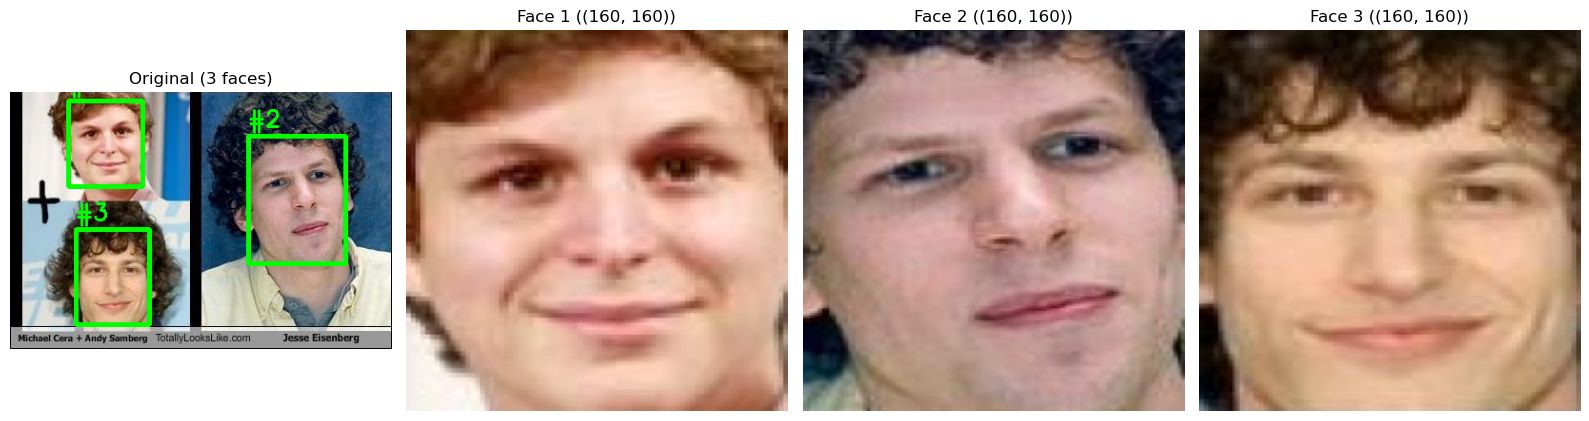

In [34]:
faces = extract_and_visualize_faces(test.iloc[1305]['img'], face_detector)

In [35]:
predict_with_cascade([test.iloc[1305]['img']], clf, cascade_ms_clf, cascade_js_clf, extract_facenet_features_batch, face_detector)

([np.int64(1)],
 array([[0.85380638, 0.05179589, 0.01391666, 0.01487907, 0.06560199],
        [0.12060218, 0.82566191, 0.00916813, 0.00818534, 0.03638244],
        [0.09963282, 0.24959296, 0.06773361, 0.01356192, 0.56947868]]))

In [37]:
final_test_predictions = [x if x in (0, 1, 2) else 0 for x in final_test_predictions]

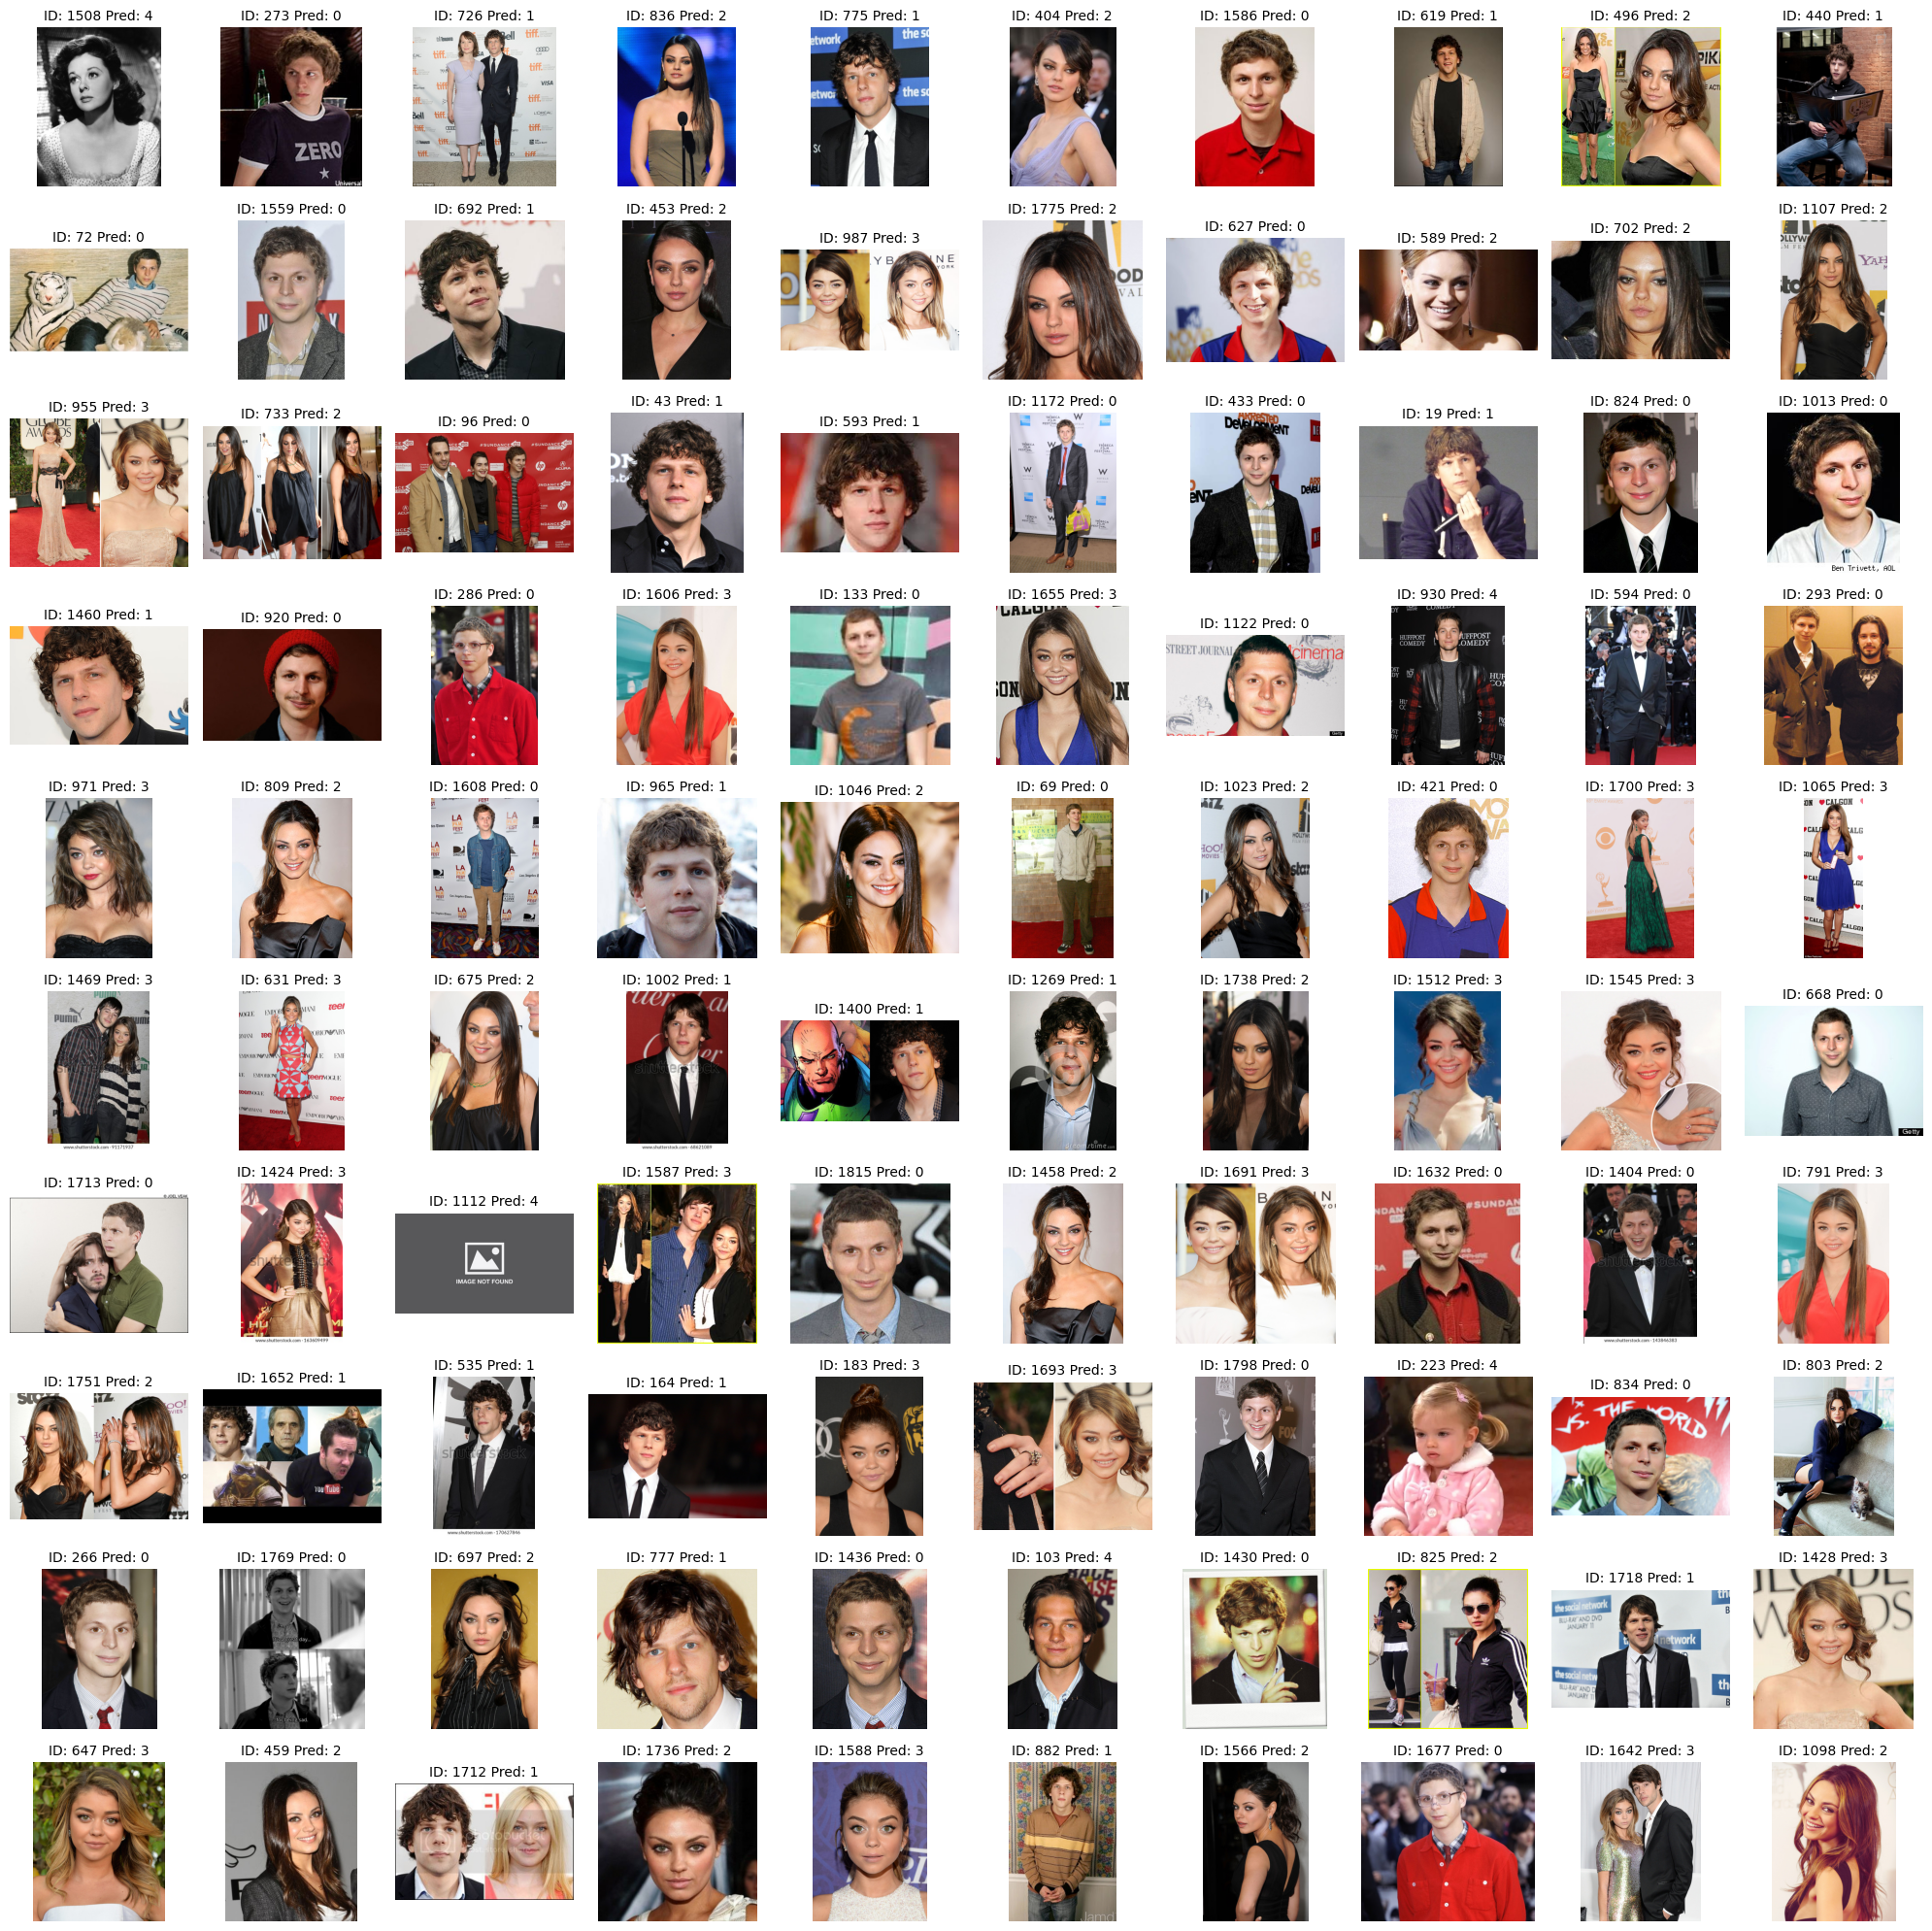

In [222]:
# 1. Load the labels back from your saved file
if final_test_predictions:
    labels = np.array(final_test_predictions)
else:
    submission_df = pd.read_csv('submission.csv')
    labels = submission_df['class'].values

# 2. Setup the plotting grid (10x10)
fig, axes = plt.subplots(10, 10, figsize=(20, 20))
axes = axes.flatten() # Flatten so we can iterate with a single index
check = set()

for i in range(100):
    rnd = random.randint(0, len(test) - 1) # Randomly sample an index to display
    while rnd in check: # Ensure we don't display the same image twice
        rnd = random.randint(0, len(test) - 1)
    check.add(rnd)
    # Display the image from your 'test' dataframe
    # Assuming 'img' column contains the pixel arrays
    axes[i].imshow(test.iloc[rnd]['img'])
    
    # Set the title using the 'class' we just extracted
    axes[i].set_title(f"ID: {rnd} Pred: {labels[rnd]}", fontsize=10)
    axes[i].axis('off')

plt.tight_layout()
plt.show()

In [38]:
submission = test.copy().drop('img', axis=1)
submission = submission.drop('predictions', axis=1)
submission['class'] = final_test_predictions
submission.to_csv('submission.csv')

print(f"Saved {len(submission)} predictions to submission.csv")
submission.head()

Saved 1816 predictions to submission.csv


,class
id,
0,1
1,0
2,0
3,0
4,1
